Tree entries = 50000
vlm=1: entries = 57057.0
vlm=2: entries = 36337.0
vlm=3: entries = 20216.0
vlm=4: entries = 14373.0
vlm=5: entries = 0.0
vlm=6: entries = 0.0
vlm=7: entries = 0.0
vlm=8: entries = 0.0
vlm=9: entries = 0.0
vlm=10: entries = 0.0


Info in <TCanvas::Print>: png file et_vlm_plot.png has been created


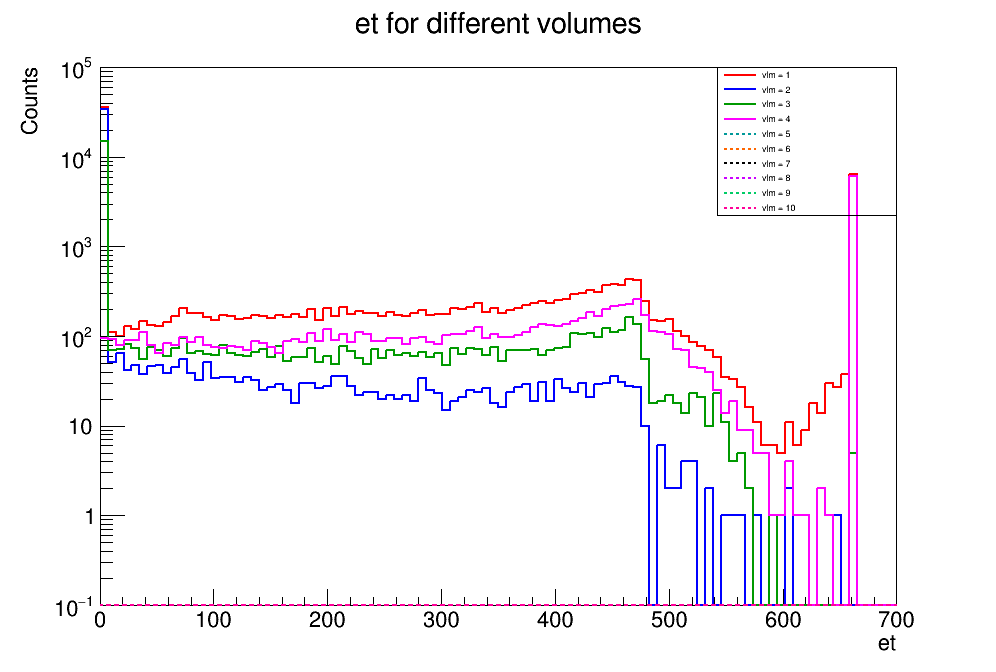

In [1]:
import ROOT
from IPython.display import Image, display

%jsroot on

f = ROOT.TFile.Open("tumor.root")
t = f.Get("t")

print("Tree entries =", t.GetEntries())

# canvas
c = ROOT.TCanvas("c", "et for different volumes", 1000, 700)
c.cd()
c.SetLogy()

legend = ROOT.TLegend(0.72, 0.68, 0.90, 0.90)
legend.SetBorderSize(1)
legend.SetFillStyle(0)

colors = [
    ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2, ROOT.kMagenta,
    ROOT.kCyan+2, ROOT.kOrange+7, ROOT.kBlack,
    ROOT.kViolet, ROOT.kTeal+2, ROOT.kPink+7
]

hist_list = []
first = True

for i, vlm in enumerate(range(1, 11)):
    hname = f"h_vlm_{vlm}"

    old = ROOT.gROOT.FindObject(hname)
    if old:
        old.Delete()

    h = ROOT.TH1F(hname, "et for different volumes;et;Counts", 100, 0, 700)
    t.Draw(f"et>>{hname}", f"vlm=={vlm}", "goff")

    print(f"vlm={vlm}: entries =", h.GetEntries())

    h.SetLineColor(colors[i % len(colors)])
    h.SetLineWidth(2)
    h.SetStats(0)

    if h.GetEntries() == 0:
        h.SetLineStyle(2)   # dashed for empty volumes

    if first:
        h.SetMinimum(0.1)   # needed for log y
        h.SetMaximum(1e5)   # optional, adjust if needed
        h.Draw("hist")
        first = False
    else:
        h.Draw("hist same")

    legend.AddEntry(h, f"vlm = {vlm}", "l")
    hist_list.append(h)

legend.Draw()
c.Modified()
c.Update()

# save and display
c.SaveAs("et_vlm_plot.png")
display(Image(filename="et_vlm_plot.png"))